In [214]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

con = duckdb.connect('../capillary.db')

df = con.execute(""" 
                 SELECT id, value, pid,delimit_value, delimit_value2,analysis, protein_value, label, interpretation
                 FROM protein_data 
                 WHERE value IS NOT NULL
                 AND delimit_value IS NOT NULL
                 AND delimit_value2 IS NOT NULL
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()

pids = con.execute("SELECT DISTINCT pid FROM protein_data").df()


con.close()

valtrain_pids, test_pids = train_test_split(pids, test_size=0.15,random_state=25)
train_pids, val_pids = train_test_split(valtrain_pids, test_size=0.15,random_state=25)

test_rows = df[ df['pid'].isin(test_pids['pid'].tolist()) ]
val_rows = df[ df['pid'].isin(val_pids['pid'].tolist()) ]
train_rows = df[ df['pid'].isin(train_pids['pid'].tolist()) ]


id_train = train_rows['id'].to_numpy()
id_val   = val_rows['id'].to_numpy()
id_test  = test_rows['id'].to_numpy()



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [215]:
## Sammantaget!
import importlib
import full_model
importlib.reload(full_model)
from full_model import predict

train_rows = predict(id_train,df)


Using mps device


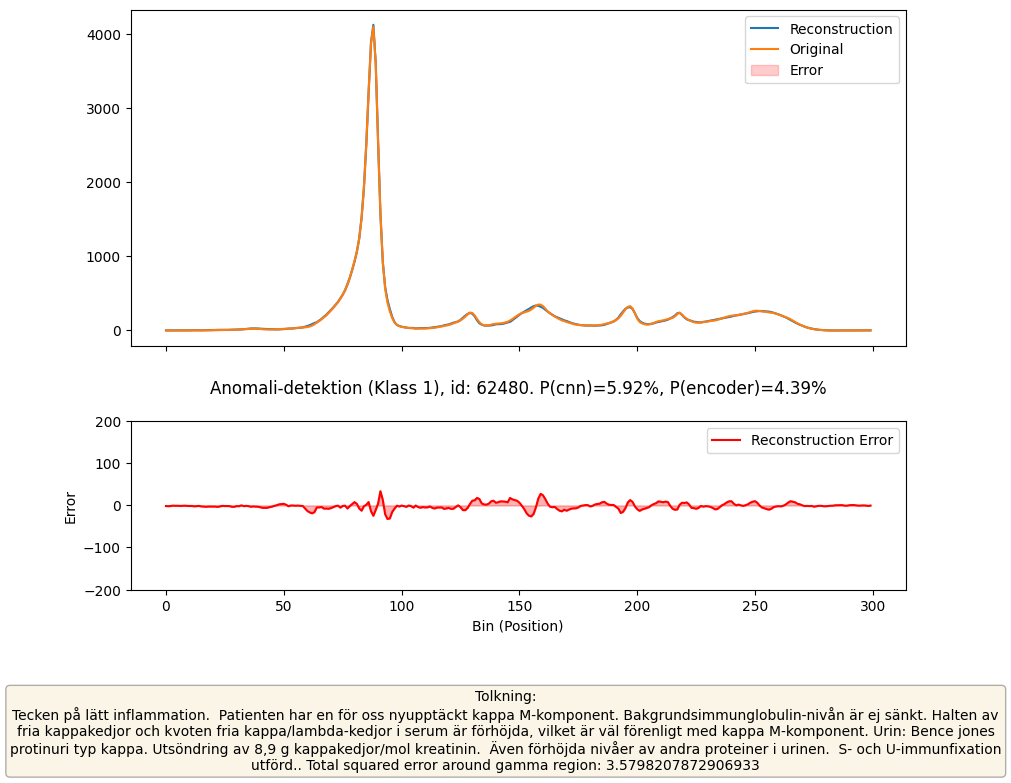

In [216]:
sorted = train_rows.sort_values('total_squared_error_gamma_region').reset_index(drop=True)
idx = 5000

subset = sorted[sorted['label'] == 1]
idx = subset['total_squared_error_gamma_region'].nsmallest(10000).index[4] #här kan man plocka outliers

# 1. Gör hela figuren högre (8 istället för 5-6)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True, 
                            gridspec_kw={'height_ratios': [2, 1]})

plt.title(f"Anomali-detektion (Klass {sorted.loc[idx,'label']}), id: {sorted.loc[idx,'id']}. P(cnn)={sorted.loc[idx,'cnn_probability']*100:.2f}%, P(encoder)={sorted.loc[idx,'encoder_probability']*100:.2f}%", pad=20)
plt.subplots_adjust(bottom=0.3,hspace=0.3) 

ax1.plot(sorted.loc[idx,'reconstructions'], label='Reconstruction', linewidth=1.5)
ax1.plot(sorted.loc[idx,'value'], label='Original', linewidth=1.5)
ax1.fill_between(range(300), sorted.loc[idx,'value'], sorted.loc[idx,'reconstructions'], color='red', alpha=0.2, label='Error')

ax1.legend()

error = sorted.loc[idx,'value'] - sorted.loc[idx,'reconstructions']
ax2.plot(error, color='red', label='Reconstruction Error')
ax2.fill_between(range(300), error, color='red', alpha=0.3)
ax2.set_ylabel("Error")
ax2.set_xlabel("Bin (Position)")
ax2.legend()
ax2.set_ylim((-200,200))

# Hämta ren text
tolkning_text = sorted.loc[idx,'interpretation'] + ". Total squared error around gamma region: " + str(sorted.loc[idx,'total_squared_error_gamma_region'])

# 3. Använd y-koordinat som är lägre (t.ex. 0.15) och sätt va='top'
# wrap=True fungerar bäst om vi anger en bredd för texten (width)
plt.figtext(0.5, 0.20, f"Tolkning:\n{tolkning_text}", 
            wrap=True, 
            horizontalalignment='center', 
            verticalalignment='top',
            fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.show()
    

In [217]:

from sklearn.metrics import classification_report, confusion_matrix

threshold_cnn = 0.25
threshold_encoder = 0.25


predictions = (train_rows['cnn_probability'] >= threshold_cnn) | (train_rows['encoder_probability'] >= threshold_encoder)

accuracy = sum(predictions == train_rows['label'])/len(predictions)

false_negatives = sum( (train_rows['label'] == 1) & (predictions == 0))/sum(train_rows['label'] == 1)
false_positives = sum( (train_rows['label'] == 0) & (predictions == 1))/sum(train_rows['label'] == 0)
false_negative_by_total = sum( (train_rows['label'] == 1) & (predictions == 0))/len(predictions)
false_positive_by_total = sum( (train_rows['label'] == 0) & (predictions == 1))/len(predictions)


# Hitta FN
fn_idx = np.where((train_rows['label'] == 1) & (predictions == 0))[0]
rows = (train_rows['label'] == 0) | (train_rows['label'] == 1)
predictions = predictions[rows]
labels = train_rows[rows]['label']
print(f"Antal FN: {len(fn_idx)}")
# Rapport
print(classification_report(labels, predictions, target_names=['Negativ', 'Positiv']))
print(confusion_matrix(labels, predictions))

print(f"Overall accuracy (using threshold): {100*accuracy:.2f}%")
print(f"False negative rate, i.e dangerous percentage (using threshold): {100*false_negatives:.2f}%")
print(f"False positive rate, i.e unneccesary alarm (using threshold): {100*false_positives:.2f}%")
print(f"% of all cases where a positive case was missed: {100*false_negative_by_total:.2f}%")
print(f"% of all cases where a negative case was incorrectly flagged as positive: {100*false_positive_by_total:.2f}%")


Antal FN: 98
              precision    recall  f1-score   support

     Negativ       1.00      0.97      0.99     82957
     Positiv       0.84      0.99      0.91     12564

    accuracy                           0.97     95521
   macro avg       0.92      0.98      0.95     95521
weighted avg       0.98      0.97      0.98     95521

[[80664  2293]
 [   98 12466]]
Overall accuracy (using threshold): 90.77%
False negative rate, i.e dangerous percentage (using threshold): 0.78%
False positive rate, i.e unneccesary alarm (using threshold): 2.76%
% of all cases where a positive case was missed: 0.10%
% of all cases where a negative case was incorrectly flagged as positive: 2.23%


In [218]:
false_negative_idx_cnn = (sorted['cnn_probability'] < threshold_cnn)  & (sorted['label'] == 1)
false_negative_idx_aed = (sorted['encoder_probability'] < threshold_encoder)  & (sorted['label'] == 1)
overlap = (false_negative_idx_cnn & false_negative_idx_aed)
print(f"totala falska negativa med CNN: {sum(false_negative_idx_cnn)}")
print(f"totala falska negativa med encoder: {sum(false_negative_idx_aed)}")
print(f"totala falska negativa med överlap: {sum(overlap)}")

cnn_predictions = sorted['cnn_probability'] >= threshold_cnn
encoder_predictions = sorted['encoder_probability'] >= threshold_encoder
print(f"totala andelen som överlappar: {sum(cnn_predictions == encoder_predictions) / len(cnn_predictions)*100:.2f}%")


totala falska negativa med CNN: 115
totala falska negativa med encoder: 1956
totala falska negativa med överlap: 98
totala andelen som överlappar: 94.22%


In [220]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import joblib

# X_meta har formen (N, 2) — en kolumn per modell
X_meta = np.column_stack([train_rows[rows]['cnn_probability'], train_rows[rows]['encoder_probability']])
y = labels

meta_model = LogisticRegression()
meta_model.fit(X_meta, y)
joblib.dump(meta_model, 'meta_model.pkl')
print(meta_model.coef_)

[[8.65684899 3.83748239]]


In [228]:
import full_model
importlib.reload(full_model)
from full_model import predict

val_data = predict(id_val,df)
X_meta_val = np.column_stack([val_data['cnn_probability'], val_data['encoder_probability']])
predictions = meta_model.predict(X_meta_val)
predictions = val_data['prediction']

rows = (val_data['label'] == 0) | (val_data['label'] == 1)
predictions=predictions[rows]

print(classification_report(val_data[rows]['label'], predictions, target_names=['Negativ', 'Positiv']))
print(confusion_matrix(val_data[rows]['label'], predictions))

accuracy = sum(predictions == val_data[rows]['label'])/len(predictions)

false_negatives = sum( (val_data[rows]['label'] == 1) & (predictions == 0))/sum(val_data['label'] == 1)
false_positives = sum( (val_data[rows]['label'] == 0) & (predictions == 1))/sum(val_data['label'] == 0)
false_negative_by_total = sum( (val_data[rows]['label'] == 1) & (predictions == 0))/len(predictions)
false_positive_by_total = sum( (val_data[rows]['label'] == 0) & (predictions == 1))/len(predictions)

print(f"Overall accuracy (using threshold): {100*accuracy:.2f}%")
print(f"False negative rate, i.e dangerous percentage (using threshold): {100*false_negatives:.2f}%")
print(f"False positive rate, i.e unneccesary alarm (using threshold): {100*false_positives:.2f}%")
print(f"% of all cases where a positive case was missed: {100*false_negative_by_total:.2f}%")
print(f"% of all cases where a negative case was incorrectly flagged as positive: {100*false_positive_by_total:.2f}%")


Using mps device
              precision    recall  f1-score   support

     Negativ       1.00      0.97      0.99     14324
     Positiv       0.86      0.99      0.92      2305

    accuracy                           0.98     16629
   macro avg       0.93      0.98      0.95     16629
weighted avg       0.98      0.98      0.98     16629

[[13961   363]
 [   26  2279]]
Overall accuracy (using threshold): 97.66%
False negative rate, i.e dangerous percentage (using threshold): 1.13%
False positive rate, i.e unneccesary alarm (using threshold): 2.53%
% of all cases where a positive case was missed: 0.16%
% of all cases where a negative case was incorrectly flagged as positive: 2.18%


In [231]:
#testar på test-datan!
test_data = predict(id_test,df)
rows= (test_data['label'] == 0) | (test_data['label'] == 1)

print(classification_report(test_data[rows]['label'], test_data[rows]['prediction'], target_names=['Negativ', 'Positiv']))
print(confusion_matrix(test_data[rows]['label'], test_data[rows]['prediction']))

accuracy = sum(test_data[rows]['prediction'] == test_data[rows]['label'])/len(test_data[rows]['prediction'])

false_negatives = sum( (test_data[rows]['label'] == 1) & (test_data[rows]['prediction'] == 0))/sum(test_data[rows]['label'] == 1)
false_positives = sum( (test_data[rows]['label'] == 0) & (test_data[rows]['prediction'] == 1))/sum(test_data[rows]['label'] == 0)
false_negative_by_total = sum( (test_data[rows]['label'] == 1) & (test_data[rows]['prediction'] == 0))/len(test_data[rows])
false_positive_by_total = sum( (test_data[rows]['label'] == 0) & (test_data[rows]['prediction'] == 1))/len(test_data[rows])

print(f"Overall accuracy (using threshold): {100*accuracy:.2f}%")
print(f"False negative rate, i.e dangerous percentage (using threshold): {100*false_negatives:.2f}%")
print(f"False positive rate, i.e unneccesary alarm (using threshold): {100*false_positives:.2f}%")
print(f"% of all cases where a positive case was missed: {100*false_negative_by_total:.2f}%")
print(f"% of all cases where a negative case was incorrectly flagged as positive: {100*false_positive_by_total:.2f}%")


Using mps device
              precision    recall  f1-score   support

     Negativ       1.00      0.98      0.99     17014
     Positiv       0.86      0.99      0.92      2414

    accuracy                           0.98     19428
   macro avg       0.93      0.98      0.95     19428
weighted avg       0.98      0.98      0.98     19428

[[16618   396]
 [   33  2381]]
Overall accuracy (using threshold): 97.79%
False negative rate, i.e dangerous percentage (using threshold): 1.37%
False positive rate, i.e unneccesary alarm (using threshold): 2.33%
% of all cases where a positive case was missed: 0.17%
% of all cases where a negative case was incorrectly flagged as positive: 2.04%


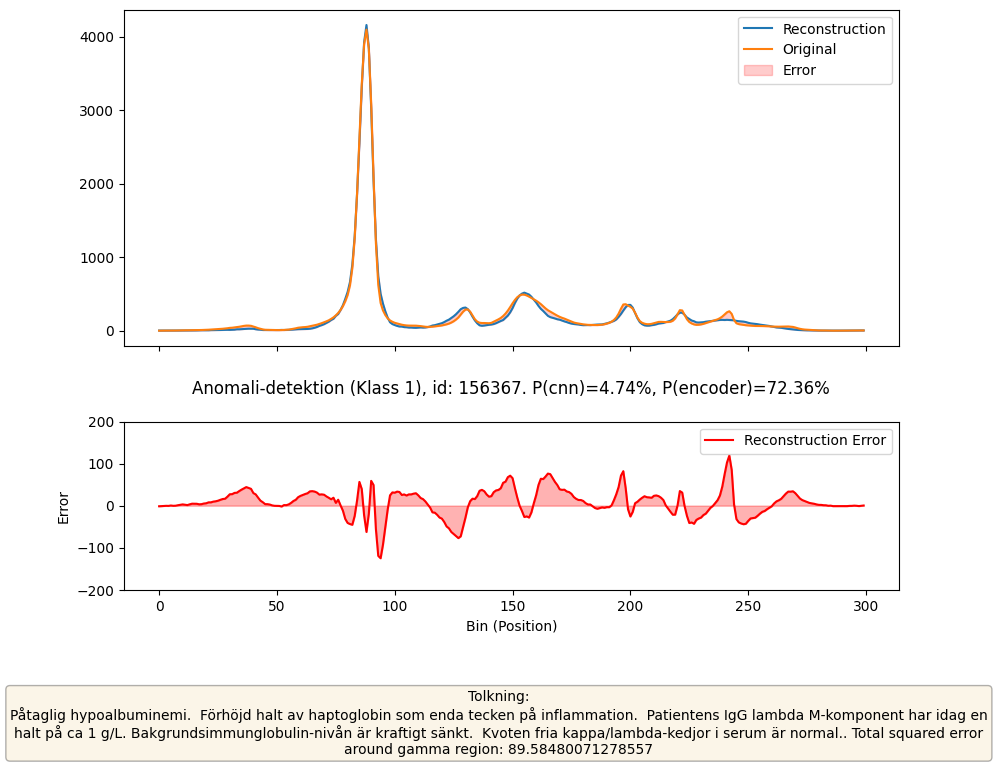

In [223]:
#Undersök intressanta fall
fn_idxs = test_data.index[ (test_data['label'] == 1) & (test_data['prediction'] == 0)]
fp_idxs = test_data.index[ (test_data['label'] == 0) & (test_data['prediction'] == 1)]
encoder_correct_cnn_missed = test_data.index[ (test_data['label'] == 1) & (test_data['cnn_probability'] < threshold_cnn) & (test_data['encoder_probability'] >= threshold_encoder) ]
cnn_correct_encoder_missed = test_data.index[ (test_data['label'] == 1) & (test_data['cnn_probability'] >= threshold_cnn) & (test_data['encoder_probability'] < threshold_encoder) ]
class_2 = test_data.index[test_data['label'] == 2]
class_4 = test_data.index[test_data['label'] == 4]

idx = encoder_correct_cnn_missed[11]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True, 
                            gridspec_kw={'height_ratios': [2, 1]})
plt.title(f"Anomali-detektion (Klass {test_data.loc[idx,'label']}), id: {test_data.loc[idx,'id']}. P(cnn)={test_data.loc[idx,'cnn_probability']*100:.2f}%, P(encoder)={test_data.loc[idx,'encoder_probability']*100:.2f}%", pad=20)
plt.subplots_adjust(bottom=0.3,hspace=0.3) 
ax1.plot(test_data.loc[idx,'reconstructions'], label='Reconstruction', linewidth=1.5)
ax1.plot(test_data.loc[idx,'value'], label='Original', linewidth=1.5)
ax1.fill_between(range(300), test_data.loc[idx,'value'], test_data.loc[idx,'reconstructions'], color='red', alpha=0.2, label='Error')
ax1.legend()
error = test_data.loc[idx,'value'] - test_data.loc[idx,'reconstructions']
ax2.plot(error, color='red', label='Reconstruction Error')
ax2.fill_between(range(300), error, color='red', alpha=0.3)
ax2.set_ylabel("Error")
ax2.set_xlabel("Bin (Position)")
ax2.legend()
ax2.set_ylim((-200,200))
tolkning_text = test_data.loc[idx,'interpretation'] + ". Total squared error around gamma region: " + str(test_data.loc[idx,'total_squared_error_gamma_region'])
plt.figtext(0.5, 0.20, f"Tolkning:\n{tolkning_text}", wrap=True, horizontalalignment='center', verticalalignment='top',fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
plt.show()